# 1 TLS Giant-Atom Open-Waveguide Example

This example runs the non-Markovian giant-atom simulation in one function: parameter input, time evolution, expectation values, and plotting.

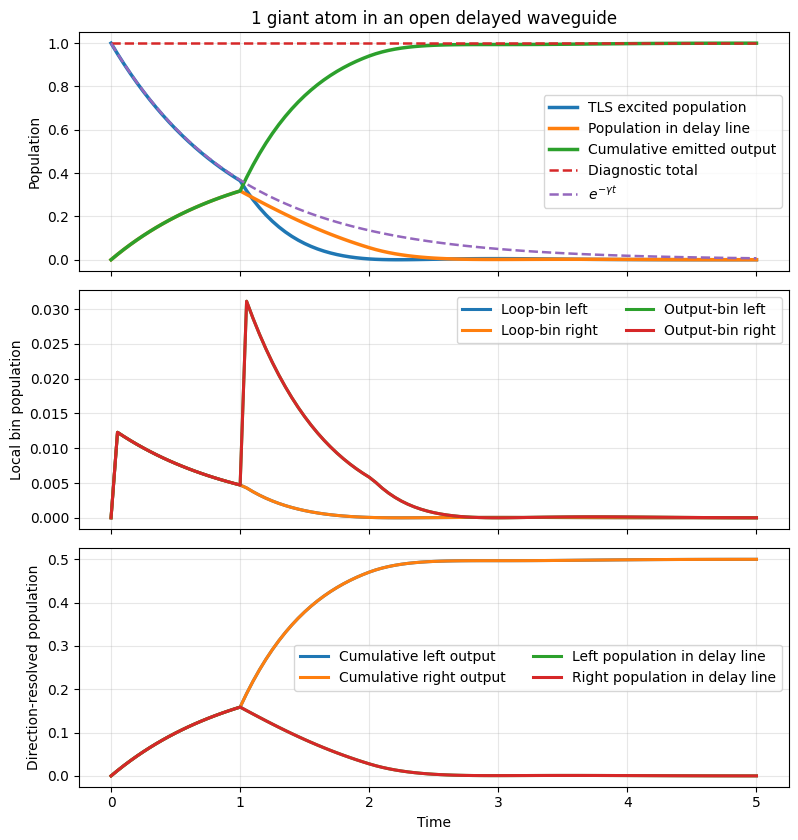

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import time as t
import wqedmps as qmps


def _delay_window_total(per_bin: np.ndarray, delay_steps: int) -> np.ndarray:
    """Accumulate the population currently stored over one delay window."""
    values = np.asarray(per_bin, dtype=float)
    if delay_steps <= 0:
        return np.zeros_like(values)

    csum = np.cumsum(values)
    total = csum.copy()
    if len(values) > delay_steps:
        total[delay_steps:] = csum[delay_steps:] - csum[:-delay_steps]
    return total


def run_giant_atom_open_example() -> tuple[
    qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]
]:
    """Run the giant-atom open-waveguide delayed example end-to-end."""
    # 1. Define physical and numerical parameters.
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=5,
        tau=1,
        d_sys_total=np.array([2]),
        d_t_total=np.array([2, 2]),
        gamma_l=0.25,
        gamma_r=0.25,
        gamma_l2=0.25,
        gamma_r2=0.25,
        phase=0,
        bond_max=18,
        atol=1e-12,
    )

    # 2. Build the initial state and local Hamiltonian.
    initial_system = qmps.tls_excited()
    initial_field = qmps.wg_ground(params.d_t)
    start_time = t.time()
    hamiltonian = qmps.hamiltonian_1tls_giant_open_nmar(params)

    # 3. Run the delayed time evolution.
    bins = qmps.t_evol_nmar_seemps(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    # 4. Compute system and field observables.
    times = np.asarray(bins.times, dtype=float)
    tls_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, qmps.tls_pop(params.d_sys)),
        dtype=float,
    )
    loop_bin_pop = np.asarray(
        qmps.single_time_expectation(
            bins.loop_field_states,
            [qmps.num_op_l(params.d_t_total), qmps.num_op_r(params.d_t_total)],
        ),
        dtype=float,
    )
    feedback_bin_pop = np.asarray(
        qmps.single_time_expectation(
            bins.output_field_states,
            [qmps.num_op_l(params.d_t_total), qmps.num_op_r(params.d_t_total)],
        ),
        dtype=float,
    )
    input_bin_pop = np.asarray(
        qmps.single_time_expectation(
            bins.input_field_states,
            [qmps.num_op_l(params.d_t_total), qmps.num_op_r(params.d_t_total)],
        ),
        dtype=float,
    )

    delay_total_l = _delay_window_total(loop_bin_pop[0], params.delay_steps)
    delay_total_r = _delay_window_total(loop_bin_pop[1], params.delay_steps)
    emitted_l = np.cumsum(feedback_bin_pop[0])
    emitted_r = np.cumsum(feedback_bin_pop[1])
    total_excitation = tls_pop + delay_total_l + delay_total_r + emitted_l + emitted_r

    runtime = float(t.time() - start_time)
    observables = {
        "times": times,
        "tls_pop": tls_pop,
        "loop_bin_pop_l": loop_bin_pop[0],
        "loop_bin_pop_r": loop_bin_pop[1],
        "feedback_bin_pop_l": feedback_bin_pop[0],
        "feedback_bin_pop_r": feedback_bin_pop[1],
        "input_bin_pop_l": input_bin_pop[0],
        "input_bin_pop_r": input_bin_pop[1],
        "delay_total_l": delay_total_l,
        "delay_total_r": delay_total_r,
        "emitted_l": emitted_l,
        "emitted_r": emitted_r,
        "total_excitation": total_excitation,
        "runtime": runtime,
        "max_abs_error": float(np.max(np.abs(total_excitation - total_excitation[0]))),
    }

    # 5. Plot population transfer and direction-resolved field observables.
    gamma_total = 1
    fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

    axes[0].plot(times, tls_pop, lw=2.5, label="TLS excited population")
    axes[0].plot(
        times, delay_total_l + delay_total_r, lw=2.5, label="Population in delay line"
    )
    axes[0].plot(
        times, emitted_l + emitted_r, lw=2.5, label="Cumulative emitted output"
    )
    axes[0].plot(times, total_excitation, "--", lw=1.8, label="Diagnostic total")
    axes[0].plot(
        times, np.exp(-gamma_total * times), "--", lw=1.8, label=rf"$e^{{-\gamma t}}$"
    )
    axes[0].set_ylabel("Population")
    axes[0].set_title("1 giant atom in an open delayed waveguide")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(times, loop_bin_pop[0], lw=2.2, label="Loop-bin left")
    axes[1].plot(times, loop_bin_pop[1], lw=2.2, label="Loop-bin right")
    axes[1].plot(times, feedback_bin_pop[0], lw=2.2, label="Output-bin left")
    axes[1].plot(times, feedback_bin_pop[1], lw=2.2, label="Output-bin right")
    axes[1].set_ylabel("Local bin population")
    axes[1].legend(ncol=2)
    axes[1].grid(alpha=0.3)

    axes[2].plot(times, emitted_l, lw=2.2, label="Cumulative left output")
    axes[2].plot(times, emitted_r, lw=2.2, label="Cumulative right output")
    axes[2].plot(times, delay_total_l, lw=2.2, label="Left population in delay line")
    axes[2].plot(times, delay_total_r, lw=2.2, label="Right population in delay line")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Direction-resolved population")
    axes[2].legend(ncol=2)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return params, bins, observables


params, bins, observables = run_giant_atom_open_example()
